# 05 — Matplotlib Plotting

**CH4114: Molecular Simulation — Tutorial 00, Part 4**

| | |
|---|---|
| **Course Instructor** | Dr. Susmita Roy |
| **TA / Author** | Shuvam Banerji Seal |

## What you will learn

- A basic 2D line plot: `plot`, `title`, `xlabel`, `ylabel`, `grid`
- Colors, line styles, markers, and legends
- **Subplots** — several figures in one grid
- **3D** surface and scatter plots
- Rotating 3D plots with your mouse

```mermaid
flowchart LR
    A[np.linspace] --> B[x values]
    B --> C[formula -> y values]
    C --> D[plt.plot x, y]
    D --> E[title + labels + grid]
    E --> F[plt.show]
```

In [1]:
# Cell 1 — imports + signing your code
# %matplotlib inline makes figures appear inside the notebook
%matplotlib inline

__author__ = "Shuvam Banerji Seal"   # sign your code — always!

import numpy as np                # for the math
import matplotlib.pyplot as plt   # for the plotting

print("matplotlib version:", plt.matplotlib.__version__)

matplotlib version: 3.11.1


## 1. Your first 2D plot

Every plot follows the same recipe:
1. make `x` values with `np.linspace`
2. compute `y` from a formula
3. `plt.plot(x, y)` then decorate (title, labels, grid)
4. `plt.show()`

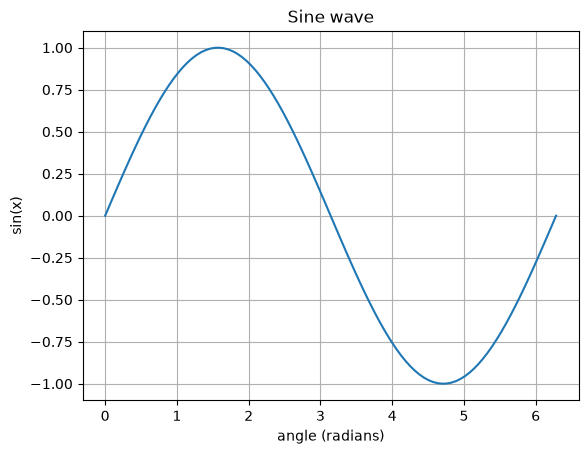

In [2]:
x = np.linspace(0, 2 * np.pi, 100)   # 100 x-values from 0 to 2*pi
y = np.sin(x)                        # sine of every x-value

plt.plot(x, y)                       # draw the curve
plt.title("Sine wave")               # give the figure a title
plt.xlabel("angle (radians)")        # label the x axis
plt.ylabel("sin(x)")                 # label the y axis
plt.grid(True)                       # add grid lines
plt.show()                           # display the figure

## 2. Colors, line styles, markers, legend

| Color ways | Examples |
|------------|----------|
| named color | `"red"`, `"blue"`, `"crimson"`, `"forestgreen"` |
| hex code | `"#2E86AB"`, `"#FF5733"` |
| RGB tuple | `(0.1, 0.4, 0.9)` |
| single letter | `'r'`, `'g'`, `'b'`, `'k'` (black) |

`linestyle="--"` gives a dashed line; `label="..."` feeds the legend.

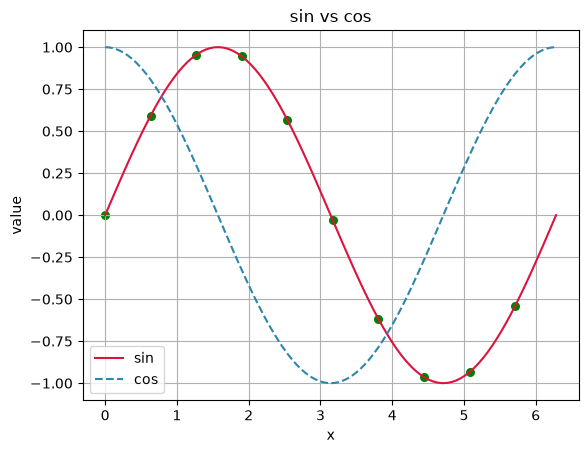

In [3]:
plt.plot(x, np.sin(x), color="crimson", label="sin")            # named color
plt.plot(x, np.cos(x), color="#2E86AB", linestyle="--", label="cos")  # hex color
plt.scatter(x[::10], np.sin(x[::10]), color="green", s=30)  # every 10th point
plt.legend()                       # show the labels in a legend box
plt.title("sin vs cos")
plt.xlabel("x")
plt.ylabel("value")
plt.grid(True)
plt.show()

## 3. Subplots — several panels in one figure

`plt.subplots(rows, cols)` returns a **figure** and an **array of axes**.
Draw in each axes with `axes[0].plot(...)`, `axes[1].plot(...)`, ...
Note: inside an axes we use `set_title`, `set_xlabel` (not `plt.title`).

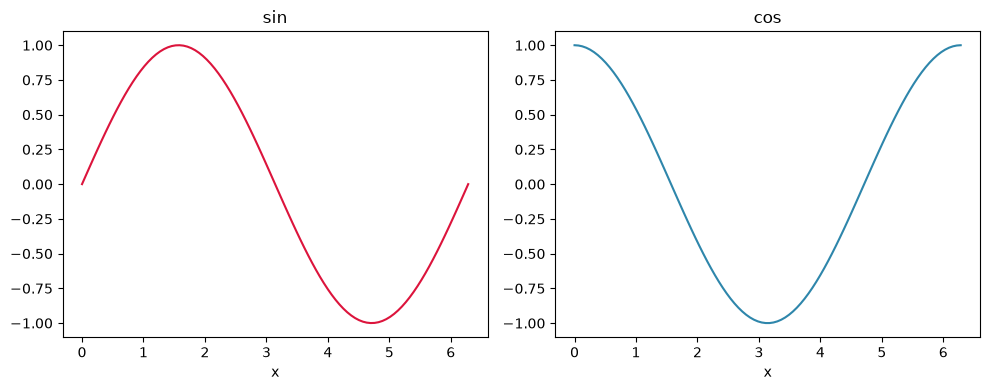

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))   # 1 row, 2 columns

axes[0].plot(x, np.sin(x), color="crimson")
axes[0].set_title("sin")          # set_title ON the axes
axes[0].set_xlabel("x")

axes[1].plot(x, np.cos(x), color="#2E86AB")
axes[1].set_title("cos")
axes[1].set_xlabel("x")

plt.tight_layout()    # stop labels from overlapping
plt.show()

## 4. 3D surface plots

For a surface we need a **grid** of (x, y) points — `np.meshgrid` builds it.
Then `z = f(x, y)` at every grid point, and `plot_surface` colors it with a
**colormap** (`cmap`): `"viridis"`, `"plasma"`, `"coolwarm"`, `"magma"`...

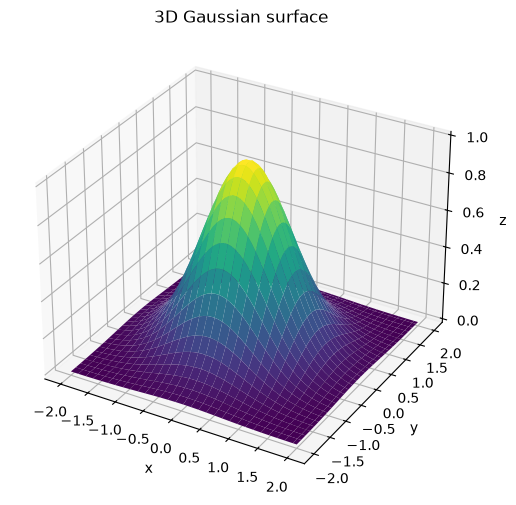

In [5]:
from mpl_toolkits.mplot3d import Axes3D   # enables 3D axes (import once)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")   # projection="3d" makes it 3D!

u = np.linspace(-2, 2, 60)               # 60 values from -2 to 2
X, Y = np.meshgrid(u, u)                 # full grid of (x, y) pairs
Z = np.exp(-(X**2 + Y**2))               # Gaussian "hill" at every point

ax.plot_surface(X, Y, Z, cmap="viridis") # draw the colored surface
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.set_title("3D Gaussian surface")
plt.show()

## 5. 3D scatter + rotating with your mouse 🖱️

`ax.scatter(xs, ys, zs)` draws points in 3D. Matplotlib's 3D axes are
**interactive by default**: drag with the left mouse button to rotate,
scroll to zoom. In Jupyter, use `%matplotlib widget` for the same effect.

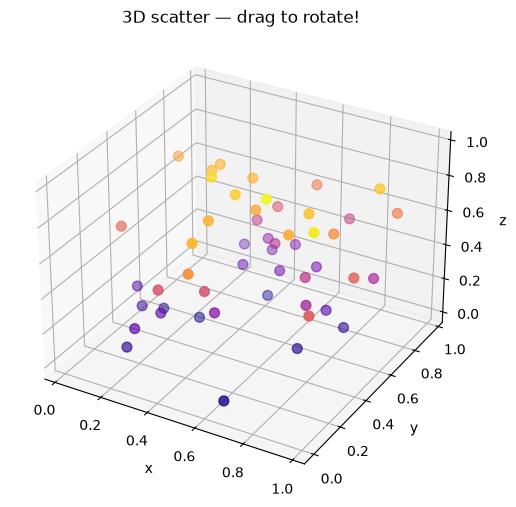

In [6]:
np.random.seed(7)                        # reproducible random points
n = 50                                   # number of points
xs = np.random.rand(n)                   # random x coordinates
ys = np.random.rand(n)                   # random y coordinates
zs = np.random.rand(n)                   # random z coordinates

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(xs, ys, zs, s=50, c=zs, cmap="plasma")   # color by z value
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.set_title("3D scatter — drag to rotate!")
plt.show()

## ✅ Check yourself

1. What does `plt.subplots(2, 2)` return? How do you draw in the top-right panel?
2. What is the difference between `plt.title` and `axes.set_title`?
3. Which function builds the (x, y) grid needed for `plot_surface`?
4. How do you rotate a 3D plot with your mouse?

**Next:** `06_lattice_structures.ipynb` — SCC, BCC, FCC lattices!